<a href="https://colab.research.google.com/github/pavlovado/Computer-Vision/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Загрузка датасета

Для реализации задачи был использован открытый набор данных [Vegetable Dataset](https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset/data), скачанный с [kaggle.com](https://www.kaggle.com).

Датасет включает в себя 21,000 изображений овощей, размером 224x224 в формате .jpg, распределенных по 15 категориям, таким как тыква, капуста, баклажан, редис и т.д.

**Структура датасета выглядит следующим образом:**
```
Vegetable_Images
|__ test
    |______ Cauliflower: [1055.jpg, 1049.jpg, 1056.jpg ...]
    |______ Carrot: [1004.jpg, 1019.jpg, 1001.jpg ...]
    |______ Pumpkin: [1065.jpg, 1070.jpg, 1046.jpg ...]
    ...
|__ train
    |______ Cauliflower: [1055.jpg, 1049.jpg, 1056.jpg ...]
    |______ Carrot: [1004.jpg, 1019.jpg, 1001.jpg ...]
    |______ Pumpkin: [1065.jpg, 1070.jpg, 1046.jpg ...]
    ...
|__ validation
    |______ Cauliflower: [1055.jpg, 1049.jpg, 1056.jpg ...]
    |______ Carrot: [1004.jpg, 1019.jpg, 1001.jpg ...]
    |______ Pumpkin: [1065.jpg, 1070.jpg, 1046.jpg ...]
    ...

```
* `test` содержит 3,000 изображений, используемых для окончательной проверки точности модели после ее обучения (~15%).
* `train` содержит 15,000 изображений, используемых для обучения модели (~70%).
* `validation` содержит 3,000 изображений, используемых для оценки модели во время тренировки и предотвращения переобучения (~15%).


**Будем следовать основному подходу при разработке моделей машинного обучения:**

1. Исследовать данные
2. Настроить поток входных данных
3. Построить модель
4. Обучить модель
5. Протестировать модель

Импортируем необходимые библиотеки и пакеты для работы с нейронными сетями.
* ` numpy ` – для работы с многомерными массивами и матрицами.
* ` matplotlib.pyplot ` – построение графиков и отображения изображений.
* ` os, shutil ` – для работы с папками, чтения файлов.
* ` tensorflow, keras ` – для создания и обучения нейронных сетей.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Dropout, MaxPooling2D
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
import os, shutil

Чтобы иметь доступ к файлам, находящимся в облачном хранилище, подключим Google Drive к Google Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Отображение изображений

Загрузим первые изображения из каждой категории в папке обучения. Для этого определяем пути к директориям и извлекаем списки файлов с помощью `os.listdir(train_path)`.

Изображения отображаются в сетке 4x4, где каждая ячейка содержит одно изображение с названием категории в заголовке. Путь к изображениям для обучения, валидации и тестирования задан в переменных train_path, validation_path и test_path. Для отображения используется matplotlib. В результате, на графике показываются изображения всех категорий с их названиями.

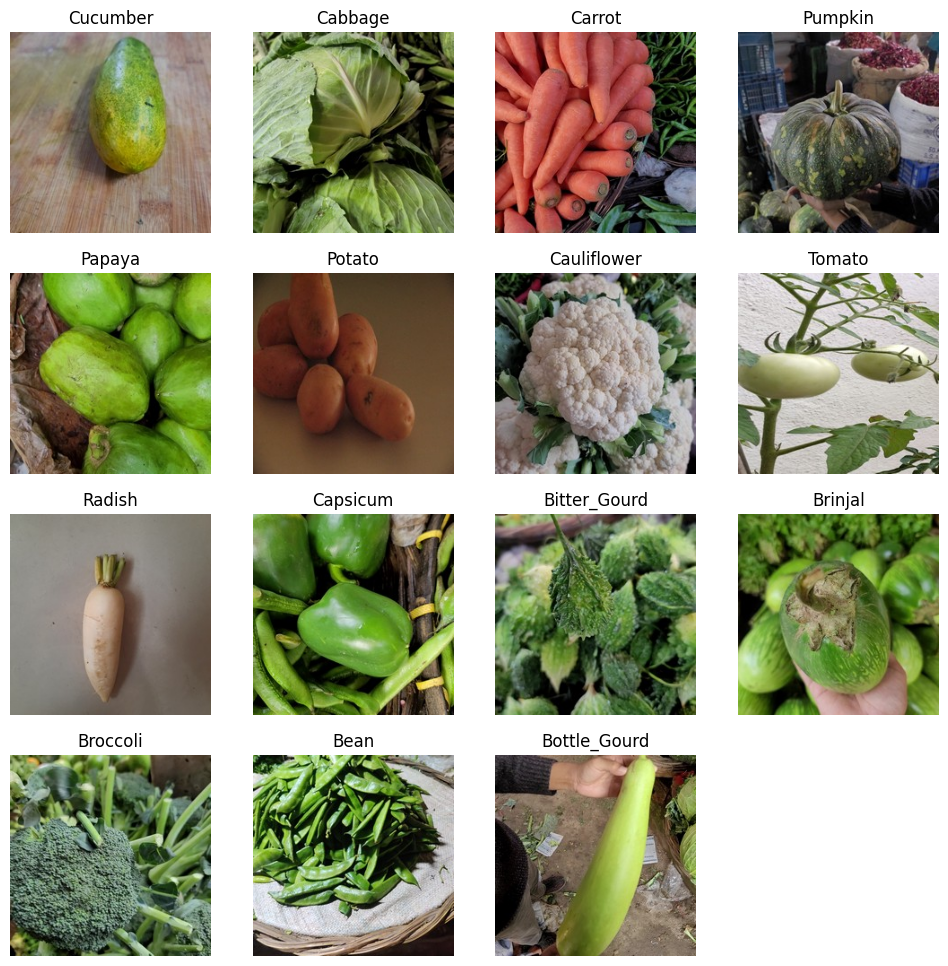

In [ ]:
train_path = '/content/drive/MyDrive/Vegetable_Images/train'
validation_path = '/content/drive/MyDrive/Vegetable_Images/validation'
test_path = '/content/drive/MyDrive/Vegetable_Images/test'

image_categories = os.listdir(train_path)

def plot_images(image_categories):
    plt.figure(figsize=(12, 12))
    for i, cat in enumerate(image_categories):

        image_path = train_path + '/' + cat
        images_in_folder = os.listdir(image_path)
        first_image_of_folder = images_in_folder[0]
        first_image_path = image_path + '/' + first_image_of_folder
        img = load_img(first_image_path)
        img_arr = img_to_array(img)/255.0

        plt.subplot(4, 4, i+1)
        plt.imshow(img_arr)
        plt.title(cat)
        plt.axis('off')

    plt.show()

plot_images(image_categories)

# Предобработка изображений

Перед тем, как изображения могут быть использованы в качестве входных данных, необходимо провести нормализацию значений пикселей из интервала от 0 до 255 к интервалу от 0 до 1, тк нейронные сети лучше работают с маленькими входными значениями.

Используем `ImageDataGenerator`, чтобы автоматически генерировать изображения из указанной директории. Генератор размечает изображения по подкатегориям, в данном случае это – train, validation и test. Генератор позволяет загружать изображения по частям, батчами, а не все сразу.

Затем изображения приводится к размеру 150x150 пикселей. Датасет разбивается на батчи по 32 изображения, что позволяет эффективно загружать данные в память и обрабатывать их партиями. Метод `flow_from_directory`загрузит изображения и выполнит данные преобразования.

In [ ]:
train_gen = ImageDataGenerator(rescale = 1.0/255.0)
train_image_generator = train_gen.flow_from_directory(
                                            train_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

val_gen = ImageDataGenerator(rescale = 1.0/255.0)
val_image_generator = val_gen.flow_from_directory(
                                            validation_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

test_gen = ImageDataGenerator(rescale = 1.0/255.0)
test_image_generator = test_gen.flow_from_directory(
                                            test_path,
                                            target_size=(150, 150),
                                            batch_size=32,
                                            class_mode='categorical')

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


Создадим словарь, который связывает числовые метки классов в обучающем наборе с их названиями. Этот шаг полезен для интерпретации результатов модели, которая будет использовать индексы для предсказаний.

Если бы мы создавали `class_map` для тестового набора данных, модель могла бы запомнить этот маппинг и «подстроиться» под него, что могло бы привести к переобучению на тестовых данных. Создание `class_map` только для обучающего набора предотвращает такую ситуацию.

In [ ]:
class_map = dict([(v, k) for k, v in train_image_generator.class_indices.items()])
print(class_map)

{0: 'Bean', 1: 'Bitter_Gourd', 2: 'Bottle_Gourd', 3: 'Brinjal', 4: 'Broccoli', 5: 'Cabbage', 6: 'Capsicum', 7: 'Carrot', 8: 'Cauliflower', 9: 'Cucumber', 10: 'Papaya', 11: 'Potato', 12: 'Pumpkin', 13: 'Radish', 14: 'Tomato'}


# Создание модели нейронной сети

Архитектура модели представляет собой сверточную нейронную сеть (CNN) с несколькими слоями. Модель включает два сверточных слоя, после каждого из которых следует блок со слоем подвыборки, который сохраняет только важные объекты из большого изображения за счет
уменьшения размерности данных. Используется функция активации `rely` и `softmax`. Первая дает возможность решать нелинейные задачи, а вторая – распределить вероятности для 15 категорий.

ReLU (Rectified-Linear Unit) является функцией активации по умолчанию для многих типов нейронных сетей. Она работает быстрее, чем другие
функции активации, такие как `Sigmoid`, `SELU`, `ELU`, `GELU` и т.д.

Первый сверточный слой использует 32 фильтра с размером ядра 3x3, второй слой имеет 64 фильтра с аналогичной конфигурацией. Фильтры, которые фактически перемещаются
по входным данным, выполняют поэлементное умножение
для извлечения признаков. После сверточных слоев данные проходят через слой `Flatten`, преобразующий многомерные данные в одномерный вектор, чтобы их можно было передать в полносвязанные слои.

Перед последним полносвязым слоем применяем исключение со значением 0.25, что означает, что 25% значений, поступающих на вход этому слою, будут сброшены до 0. Это поможет предотвратить переобучение. `Dropout` стоит посередине для того, чтобы уменьшить взаимозависимость между слоями.

Добавление второго полносвязного слоя помогает обучить более сложные нелинейные функции. Это особенно важно, если задача классификации предполагает наличие множества классов. Первый слой может сосредотачиваться на обучении базовых характерных особенностях, а второй — на их комбинациях. Это улучшает общее качество представлений, формируемых моделью.

In [ ]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu', input_shape=[150, 150, 3]))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu'))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(128, activation='relu'))
model.add(Dense(15, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 87616)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,214,976 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 15)                  │           1,935 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,252,815 (42.93 MB)

 Trainable params: 11,252,815 (42.93 MB)

 Non-trainable params: 0 (0.00 B)

# Обучение модели

Перед тем, как перейти к тренировке, выполним некоторые настройки, которые производятся во время сборки модели при вызове метода `compile`:
1. *Функция оптимизации* – алгоритм, который изменяет внутренние переменные при каждой итерации, с целью уменьшения значения функции потерь.
2. *Функия потерь* – алгоритм измерения того, насколько далеко находится нужное значение от прогнозируемого.
3. *Метрики* – используется для мониторинга процесса тренировки. Пример ниже использует метрику `точность` (процент изображений, которые были корректно классифицированы).

Компиляция и обучение модели нейронной сети происходит с использованием двух колбэков: `EarlyStopping` и `ModelCheckpoint`.

`EarlyStopping` позволяет остановить обучение, если валидационная ошибка не улучшается в течение 5 эпох, восстанавливая при этом лучшие веса модели. Колбэк `ModelCheckpoint` сохраняет лучшую модель, основываясь на минимальном значении валидационной ошибки.

После компиляции модель обучается на тренировочных данных в течение 40 эпох с валидацией, при этом оба колбэка используются для повышения эффективности процесса обучения.

При использовании генераторов (`train_image_generator` и `val_image_generator`) модель не знает, сколько именно данных находится в генераторе. Параметры `steps_per_epoch` и `validation_steps `задают, сколько итераций нужно сделать, чтобы обработать весь набор.



In [ ]:
early_stopping = EarlyStopping(patience=5, monitor='val_loss', mode='min', restore_best_weights=True)

checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss', mode='min')

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

hist = model.fit(
    train_image_generator,
    epochs=40,
    verbose=1,
    validation_data=val_image_generator,
    steps_per_epoch=15000 // 32, # колво шагов за эпоху обучения
    validation_steps=3000 // 32,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/40
468/468 ━━━━━━━━━━━━━━━━━━━━ 4250s 9s/step - accuracy: 0.3828 - loss: 1.8798 - val_accuracy: 0.8165 - val_loss: 0.6119
Epoch 2/40
468/468 ━━━━━━━━━━━━━━━━━━━━ 56s 116ms/step - accuracy: 0.6562 - loss: 0.8574 - val_accuracy: 0.6667 - val_loss: 0.6997
Epoch 3/40
468/468 ━━━━━━━━━━━━━━━━━━━━ 737s 2s/step - accuracy: 0.7955 - loss: 0.6214 - val_accuracy: 0.8821 - val_loss: 0.3898
Epoch 4/40
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 537us/step - accuracy: 0.7812 - loss: 1.0652 - val_accuracy: 0.9167 - val_loss: 0.4154
Epoch 5/40
468/468 ━━━━━━━━━━━━━━━━━━━━ 721s 2s/step - accuracy: 0.8792 - loss: 0.3765 - val_accuracy: 0.9059 - val_loss: 0.2917
Epoch 6/40
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.9062 - loss: 0.3213 - val_accuracy: 0.9583 - val_loss: 0.8948
Epoch 7/40
468/468 ━━━━━━━━━━━━━━━━━━━━ 760s 2s/step - accuracy: 0.9155 - loss: 0.2623 - val_accuracy: 0.9231 - val_loss: 0.2497
Epoch 8/40
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8125 - loss: 0.4730 - val_

Однако, несмотря на то, что указано 40 эпох, модель фактически прошла только 13 эпох. Это произошло из-за работы колбэка `EarlyStopping`, который остановил обучение раньше, когда валидационная ошибка не улучшалась в течение нескольких эпох, что привело к досрочному завершению обучения для предотвращения переобучения и экономии времени.








Создадим два графика для визуализации результатов обучения модели. Первый график отображает точность как на обучающем наборе данных, так и на валидационном, с метками для каждой эпохи. Второй график показывает потери на обучающих и валидационных данных, также с метками для каждой эпохи.



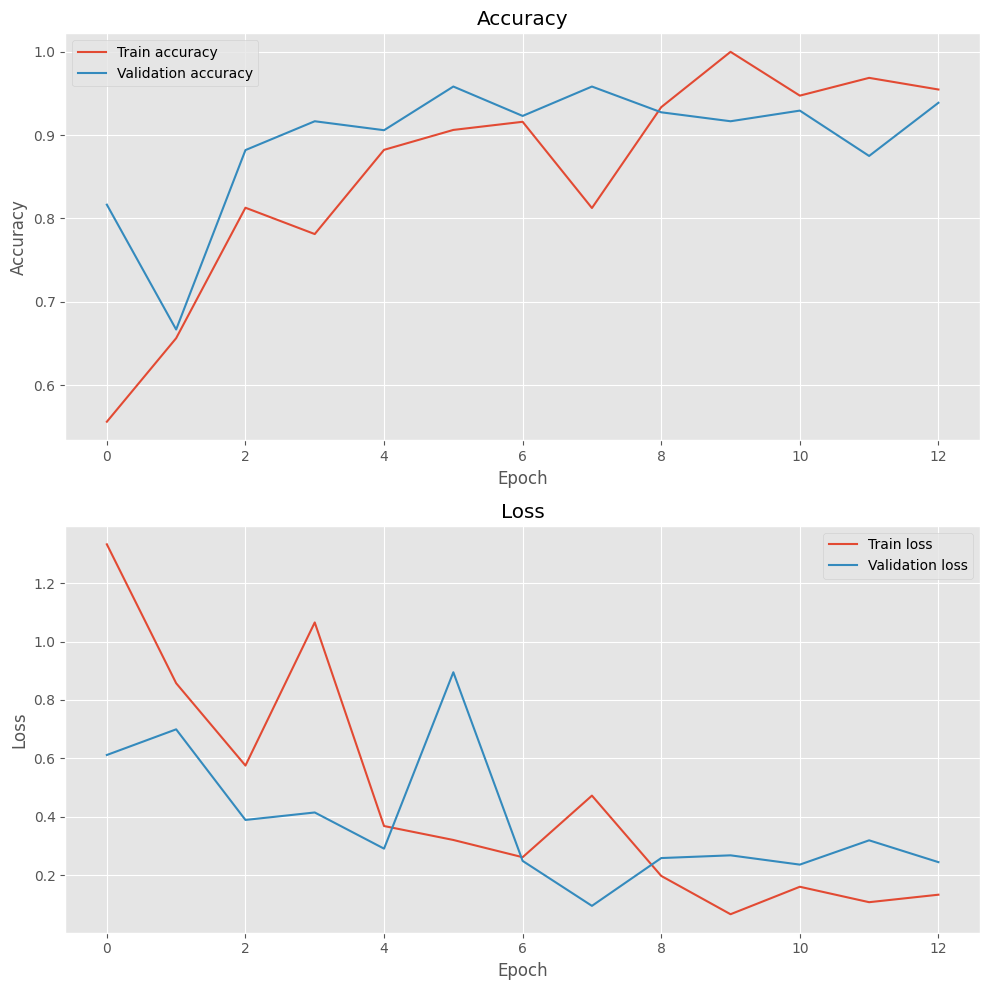

In [ ]:
h = hist.history # извлечение истории обучения

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

ax1.plot(h['accuracy'], label='Train accuracy')
ax1.plot(h['val_accuracy'], label='Validation accuracy')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(h['loss'], label='Train loss')
ax2.plot(h['val_loss'], label='Validation loss')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

**График точности**

*Обучающая точность*

Постепенный рост точности на протяжении первых 7 эпох, затем рост замедляется, и точность стабилизируется около 0,9.
Это говорит о том, что модель хорошо учится распознавать паттерны в обучающей выборке.

*Валидационная точность*

Быстро растет в первые несколько эпох, достигая 0,9, но затем колеблется около этого значения.
Максимальная точность на валидации не сильно отличается от точности на обучении, что свидетельствует об отсутствии сильного переобучения.

**График потерь**

*Обучающая потеря:*

Постоянно уменьшается на протяжении обучения, что ожидаемо, так как модель оптимизирует свои веса для минимизации ошибки.

*Валидационная потеря:*

Уменьшается на начальных эпохах, достигая минимума, но затем начинает колебаться. На некоторых эпохах валидационная потеря выше, чем обучающая. Такие колебания могут быть связаны с особенностями валидационного набора данных (например, шум или сложные примеры).

# Тестирование модели

Проверим модель на тестовых данных с помощью метода оценки модели. Точность составила 92%, а потери — 24%.

In [ ]:
model.evaluate(test_image_generator)

94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 491ms/step - accuracy: 0.9235 - loss: 0.2442


[0.2343699336051941, 0.9290000200271606]

Загрузим изображение из тестовой папки и отобразим его с прогнозируемым и реальными результатом, используя модель для предсказания.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


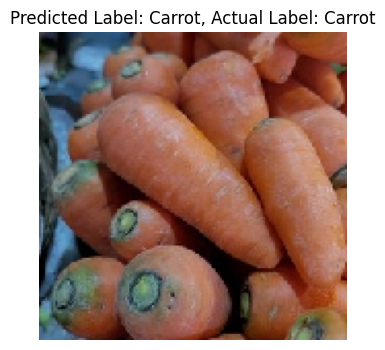

In [ ]:
test_image_path = '/content/drive/MyDrive/Vegetable_Images/test/Carrot/1028.jpg'

def generate_predictions(test_image_path, actual_label):

    test_img = image.load_img(test_image_path, target_size=(150, 150))
    test_img_arr = image.img_to_array(test_img)/255.0
    test_img_input = test_img_arr.reshape((1, test_img_arr.shape[0], test_img_arr.shape[1], test_img_arr.shape[2]))

    predicted_label = np.argmax(model.predict(test_img_input))
    predicted_vegetable = class_map[predicted_label]
    plt.figure(figsize=(4, 4))
    plt.imshow(test_img_arr)
    plt.title("Predicted Label: {}, Actual Label: {}".format(predicted_vegetable, actual_label))
    plt.grid()
    plt.axis('off')
    plt.show()

generate_predictions(test_image_path, actual_label='Carrot')

Далее протестируем модель на изображениях с интернета. Для этого скачаем картинки с указанной ссылки с Dropbox и сохраним в текущую рабочую директорию.

In [ ]:
!wget -O beans.jpg "https://www.dropbox.com/s/i020rz847u8bq09/beans.jpg?dl=1"

--2024-12-05 15:55:57--  https://www.dropbox.com/s/i020rz847u8bq09/beans.jpg?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:6019:18::a27d:412
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/9uftcircwmqvounqhxnpz/beans.jpg?rlkey=o2lthgu0qdktffn093um6z7ti&dl=1 [following]
--2024-12-05 15:55:57--  https://www.dropbox.com/scl/fi/9uftcircwmqvounqhxnpz/beans.jpg?rlkey=o2lthgu0qdktffn093um6z7ti&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucbaf8bc17a9fe4d507ae17faae3.dl.dropboxusercontent.com/cd/0/inline/CfppMN-4EBvukkwQ4Wh5Zrw6jcqwv9xVpbS0IzCdOYO2LvG9bkd4thnLnUHrsydoj9Wk2fQ6y57emJmpl5ic4Vu7UrwSHp-I95liQlOImLqzLQdKm977iYPPPrr8d2K8uBmkAwG1Iji8oDRogEbGjsUZ/file?dl=1# [following]
--2024-12-05 15:55:58--  https://ucbaf8bc17a9fe4d507ae17faae3.dl.dropboxusercontent.com/cd

In [ ]:
!wget -O potato_2.jpg "https://www.dropbox.com/s/lge1plvr4mg5w7y/potato_2.jpg?dl=1"

--2024-12-05 15:56:02--  https://www.dropbox.com/s/lge1plvr4mg5w7y/potato_2.jpg?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:6019:18::a27d:412
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/hwp4o0k4doqiatggrafgv/potato_2.jpg?rlkey=y7jnxui9jtkvku0tccwo5u46d&dl=1 [following]
--2024-12-05 15:56:03--  https://www.dropbox.com/scl/fi/hwp4o0k4doqiatggrafgv/potato_2.jpg?rlkey=y7jnxui9jtkvku0tccwo5u46d&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc5763e907d580cdf554c0d012a0.dl.dropboxusercontent.com/cd/0/inline/CfqnFSUfUl4I3MSCYyid5jDaaYlgoN4C8M7U7LlwyLAI9JsrMsaN2L34SQtQUUxDGdCs3_p0j4YW7XRxAcuSA2QC34vR2htqm_eStoys8vUT0V4Yb0LexEhqGeEqvPoOSVd9Tn6QNY4HFb-fF5HumH-M/file?dl=1# [following]
--2024-12-05 15:56:04--  https://uc5763e907d580cdf554c0d012a0.dl.dropboxuserconte

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


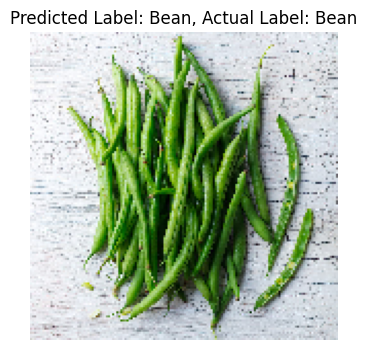

In [ ]:
external_image_path_1 = "./beans.jpg"
generate_predictions(external_image_path_1, actual_label='Bean')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


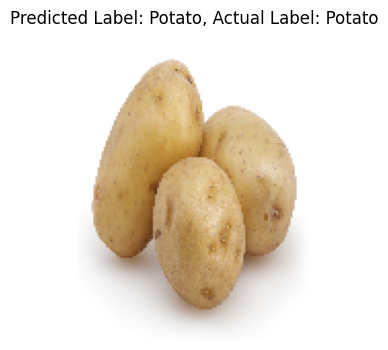

In [ ]:
external_image_path_2 = "./potato_2.jpg"
generate_predictions(external_image_path_2, actual_label='Potato')

Теперь протестируем модель на изображении, загруженного с локального
компьютера.

In [ ]:
from google.colab import files
uploaded = files.upload() #Открывает окно для загрузки файлов и Сохраняет загруженные файлы в переменной uploaded в виде словаря

for filename in uploaded.keys(): #Проходит по именам файлов
    print(f"Файл {filename} был загружен.")

Saving cauliflower.jpg to cauliflower.jpg
Файл cauliflower.jpg был загружен.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


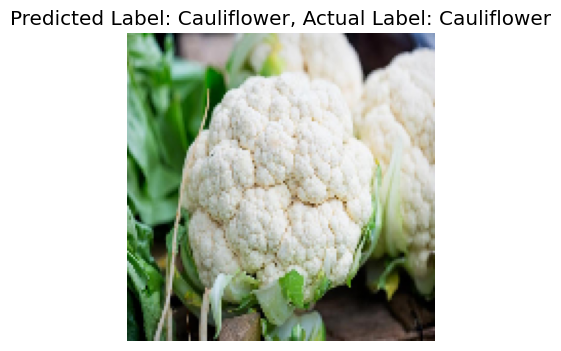

In [ ]:
external_image_path_4 = "./cauliflower.jpg"
generate_predictions(external_image_path_4, actual_label='Cauliflower')